In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

print("Path to competition files:", path)

c:\Users\axeld\VSCode\Kaggle\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to competition files: C:\Users\axeld\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques


In [2]:
from pathlib import Path
import pandas as pd

data_dir = Path(path)

print([file.name for file in data_dir.iterdir()])

train_data = pd.read_csv(data_dir / "train.csv")
train_data.head()

['data_description.txt', 'sample_submission.csv', 'test.csv', 'train.csv']


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
train_data.select_dtypes(include=["number"]).std()

Id                 421.610009
MSSubClass          42.300571
LotFrontage         24.284752
LotArea           9981.264932
OverallQual          1.382997
OverallCond          1.112799
YearBuilt           30.202904
YearRemodAdd        20.645407
MasVnrArea         181.066207
BsmtFinSF1         456.098091
BsmtFinSF2         161.319273
BsmtUnfSF          441.866955
TotalBsmtSF        438.705324
1stFlrSF           386.587738
2ndFlrSF           436.528436
LowQualFinSF        48.623081
GrLivArea          525.480383
BsmtFullBath         0.518911
BsmtHalfBath         0.238753
FullBath             0.550916
HalfBath             0.502885
BedroomAbvGr         0.815778
KitchenAbvGr         0.220338
TotRmsAbvGrd         1.625393
Fireplaces           0.644666
GarageYrBlt         24.689725
GarageCars           0.747315
GarageArea         213.804841
WoodDeckSF         125.338794
OpenPorchSF         66.256028
EnclosedPorch       61.119149
3SsnPorch           29.317331
ScreenPorch         55.757415
PoolArea  

In [4]:
train_data["MSSubClass"].value_counts()

MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64

In [5]:
len(train_data)

1460

In [6]:
train_data.isna().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [7]:
from pandas import DataFrame

label_col = "SalePrice"

def get_only_numeric_x(df: DataFrame):
    return df.select_dtypes(include="number").drop(columns=[label_col])

def get_all_x(df: DataFrame):
    cols = df.select_dtypes(include=["string"]).columns
    df[cols] = df[cols].astype("category")
    df["MSSubClass"] = df["MSSubClass"].astype("category")
    return df.drop(columns=[label_col])

def get_x(df: DataFrame):
    df = df.drop(columns=[label_col, "Id"])

def get_y(df: DataFrame):
    return df[label_col]

X = get_all_x(train_data)
y = get_y(train_data)

In [8]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42)

In [9]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
)
xgb_model

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        make_column_selector(dtype_include="number")
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        make_column_selector(dtype_include=["str", "object", "category"])
    )
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42
    ))
])

In [11]:
# from sklearn.model_selection import KFold, cross_val_score
# 
# cv = KFold(n_splits=5, shuffle=True, random_state=42)
# 
# models = {
#     "XGB": model
# }
# 
# for name, model in models.items():
#     scores = cross_val_score(model, X, y, cv=cv, scoring="neg_root_mean_squared_error")
#     print(f"{name}: {scores.mean():.3f} +- {scores.std():.3f}")

In [12]:
train_transformed = preprocessor.fit_transform(X_train)
val_transformed = preprocessor.transform(X_val)
test_transformed = preprocessor.transform(X_test)

In [13]:
import torch

torch.manual_seed(42)

device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
device

'cuda'

In [15]:
import numpy as np
from scipy import sparse
from torch.utils.data import TensorDataset, DataLoader

def make_dataset(X_transformed, y):
    if sparse.issparse(X_transformed):
        X_transformed = X_transformed.toarray()

    X_tensor = torch.from_numpy(
        np.asarray(X_transformed, dtype=np.float32)
    )
    y_tensor = torch.from_numpy(
        np.asarray(y, dtype=np.float32).reshape(-1, 1)
    )

    return TensorDataset(X_tensor, y_tensor)

target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(y_train.to_numpy().reshape(-1, 1))
y_val_scaled = target_scaler.transform(y_val.to_numpy().reshape(-1, 1))
y_test_scaled = target_scaler.transform(y_test.to_numpy().reshape(-1, 1))

train_dataset = make_dataset(train_transformed, y_train_scaled)
val_dataset = make_dataset(val_transformed, y_val_scaled)
test_dataset = make_dataset(test_transformed, y_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [16]:
@torch.no_grad()
def eval(model, val_loader, criterion, metric):
    model.eval()
    metric.reset()

    total_loss = 0.0
    total_samples = 0

    for X, y in val_loader:
        X = X.to(device)
        y = y.to(device)

        predictions = model(X)
        loss = criterion(predictions, y)

        total_loss += loss.item() * len(y)
        total_samples += len(y)

        metric.update(predictions, y)

    return {
        "loss": total_loss / total_samples,
        "metric": metric.compute().item()
    }


def train(model, train_loader, val_loader, criterion, optimizer, metric, n_epochs):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_metric": []
    }

    for epoch in range(n_epochs):
        model.train()
        metric.reset()

        total_loss = 0.0
        total_samples = 0

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            predictions = model(X)

            optimizer.zero_grad()

            loss = criterion(predictions, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y)
            total_samples += len(y)

        train_loss = total_loss / total_samples
        val = eval(model, val_loader, criterion, metric)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val["loss"])
        history["val_metric"].append(val["metric"])

        print(
            f"Epoch: {epoch + 1} | "
            f"Train loss: {train_loss} | "
            f"Val loss: {val["loss"]} | "
            f"Val metric: {val["metric"]}"
        )

    return history


In [21]:
import torch.nn as nn
from torch.optim import AdamW
from torchmetrics.regression import MeanSquaredError

nn_model = nn.Sequential(
    nn.Linear(train_transformed.shape[1], 32),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(32, 64),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.1),

    nn.Linear(32, 1)
).to(device)

criterion = nn.MSELoss()
optimizer = AdamW(nn_model.parameters(), lr=1e-3)
metric = MeanSquaredError(squared=False).to(device)

history = train(nn_model, train_loader, val_loader, criterion, optimizer, metric, 50)

Epoch: 1 | Train loss: 0.7694198115670478 | Val loss: 0.5689200225042149 | Val metric: 0.7542678713798523
Epoch: 2 | Train loss: 0.32547871372618303 | Val loss: 0.2457011009760719 | Val metric: 0.4956824779510498
Epoch: 3 | Train loss: 0.2806980422144823 | Val loss: 0.19114456198272858 | Val metric: 0.4372008442878723
Epoch: 4 | Train loss: 0.22235928764266352 | Val loss: 0.1962434778159315 | Val metric: 0.44299376010894775
Epoch: 5 | Train loss: 0.18997998312257047 | Val loss: 0.18112900056303505 | Val metric: 0.4255925416946411
Epoch: 6 | Train loss: 0.20980012015328237 | Val loss: 0.19611328186835836 | Val metric: 0.44284680485725403
Epoch: 7 | Train loss: 0.18871426194962784 | Val loss: 0.18024692313875107 | Val metric: 0.4245549738407135
Epoch: 8 | Train loss: 0.17174905880691882 | Val loss: 0.17281140406979598 | Val metric: 0.41570591926574707
Epoch: 9 | Train loss: 0.17301903559032836 | Val loss: 0.2397583868892435 | Val metric: 0.48965126276016235
Epoch: 10 | Train loss: 0.1671

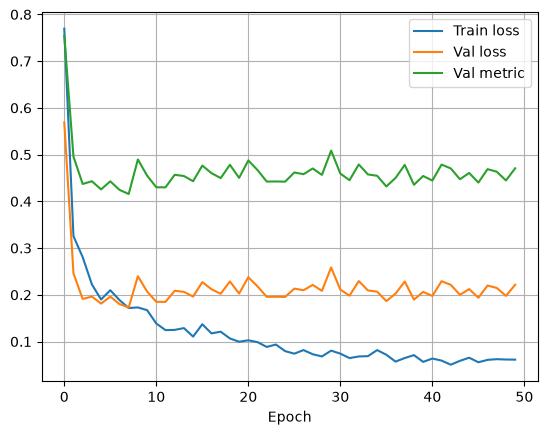

In [ ]:
import matplotlib.pyplot as plt

epochs = range(len(history["train_loss"]))

plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"], label="Val loss")

plt.xlabel("Epoch")
plt.grid(True)
plt.legend()
plt.show()

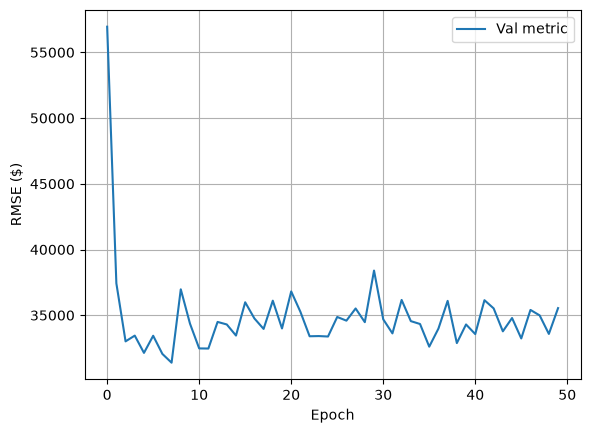

In [24]:
import matplotlib.pyplot as plt

epochs = range(len(history["val_metric"]))
rmse_dollars = np.asarray(history["val_metric"]) * target_scaler.scale_[0]

plt.plot(epochs, rmse_dollars, label="Val metric")

plt.xlabel("Epoch")
plt.ylabel("RMSE ($)")
plt.grid(True)
plt.legend()
plt.show()